In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

# Percentiles

In [3]:
(75/100)*5

3.75

In [4]:
3/5

0.6

In [5]:
4/5

0.8

In [6]:
(30/100)*9

2.6999999999999997

In [7]:
3/9

0.3333333333333333

In [8]:
2/9

0.2222222222222222

In [9]:
45/100*9

4.05

In [10]:
89/100*9

8.01

In [11]:
percentile(30, make_array(4, 11, 12, 13, 15, 17, 18, 23, 24))

12

In [12]:
percentile(89, make_array(4, 11, 12, 13, 15, 17, 18, 23, 24))

24

In [14]:
nums = make_array(8, 6, 7, 5, 3, 0, 9)
np.sort(nums) # this does *not* change nums

array([0, 3, 5, 6, 7, 8, 9])

In [15]:
nums

array([8, 6, 7, 5, 3, 0, 9])

In [16]:
percentile(75, np.sort(nums))

8

In [18]:
percentile(75, nums)

8

In [19]:
percentile(25, nums)

3

In [20]:
percentile(50, make_array(1, 1, 3, 5, 7, 8, 10, 11, 11, 15))

7

In [21]:
np.median(make_array(1, 1, 3, 5, 7, 8, 10, 11, 11, 15))

7.5

In [24]:
percentile(50, make_array(4, 5, 6, 7, 8, 11))

6

# Bootstrapping

In [26]:
# it's almost never possible to have the entire population, but we're going to practice to one
# all we usually get are samples
population = Table.read_table('data/san_francisco_2019.csv')
population.sample(10)

Organization Group,Department,Job Family,Job,Salary,Overtime,Benefits,Total Compensation
Public Protection,Juvenile Court,Correction & Detention,"Counselor, Juvenile Hall PERS",86644,6780,46938,140362
"Public Works, Transportation & Commerce",Municipal Transportation Agcy,Protection & Apprehension,Parking Control Officer,72559,1145,36077,109781
"Public Works, Transportation & Commerce",Department Of Public Works,Sub-Professional Engineering,"StdntDsgnTrain1, Arch/Eng/Plng",25824,0,2004,27828
Community Health,Public Health,"Clerical, Secretarial & Steno",Clerk,53803,0,31884,85687
General Administration & Finance,Human Resources,"Budget, Admn & Stats Analysis",Management Assistant,86647,0,39419,126066
Culture & Recreation,Recreation And Park Commission,Recreation,Swimming Instructor,2874,0,223,3097
Public Protection,Juvenile Court,Probation & Parole,Deputy Probation Officer,45140,3504,11801,60445
General Administration & Finance,City Attorney,"Clerical, Secretarial & Steno",Legal Secretary 1,90586,0,39997,130583
"Public Works, Transportation & Commerce",Municipal Transportation Agcy,Street Transit,Transit Operator,56394,7941,33409,97743
Public Protection,Fire Department,Fire Services,EMT/Paramedic/Firefighter,156878,61,50493,207432


In [28]:
population.sort('Total Compensation', descending=True)

Organization Group,Department,Job Family,Job,Salary,Overtime,Benefits,Total Compensation
General Administration & Finance,Retirement Services,Administrative & Mgmt (Unrep),Chief Investment Officer,577633,0,146398,724031
General Administration & Finance,Retirement Services,Unassigned,Managing Director,483072,0,134879,617951
General Administration & Finance,Retirement Services,Unassigned,Managing Director,482649,0,134905,617554
General Administration & Finance,Retirement Services,Unassigned,Managing Director,451507,0,120276,571784
General Administration & Finance,Retirement Services,Unassigned,Managing Director,449378,0,120857,570235
Community Health,Public Health,Administrative & Mgmt (Unrep),"Physician Administrator, DPH",434966,0,119213,554179
Public Protection,Sheriff,Correction & Detention,Senior Deputy Sheriff,152153,315896,77275,545324
General Administration & Finance,Retirement Services,Management,Director,397392,0,108913,506305
Community Health,Public Health,Medical & Dental,Supervising Physician Spec,404701,0,99480,504181
Community Health,Public Health,Medical & Dental,Senior Physician Specialist,400992,0,97428,498421


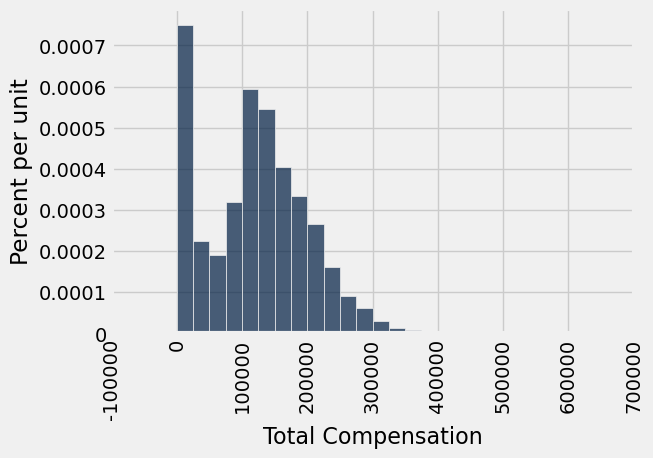

In [31]:
population.hist('Total Compensation', bins=np.arange(0, 600000, 25000))

In [32]:
population.sort('Total Compensation')

Organization Group,Department,Job Family,Job,Salary,Overtime,Benefits,Total Compensation
Public Protection,Adult Probation,Probation & Parole,Deputy Probation Officer,0,0,0,0
Public Protection,Fire Department,"Clerical, Secretarial & Steno",Senior Clerk Typist,0,0,0,0
Public Protection,Juvenile Court,Correction & Detention,"Counselor, Juvenile Hall PERS",0,0,0,0
Public Protection,Police,"Clerical, Secretarial & Steno",Clerk Typist,0,0,0,0
Public Protection,Sheriff,Correction & Detention,Deputy Sheriff,0,0,0,0
"Public Works, Transportation & Commerce",Airport Commission,Sub-Professional Engineering,StdntDsgn Train2/Arch/Eng/Plng,0,0,0,0
"Public Works, Transportation & Commerce",Airport Commission,"Clerical, Secretarial & Steno",Executive Secretary 1,0,0,0,0
"Public Works, Transportation & Commerce",Airport Commission,"Payroll, Billing & Accounting",Senior Account Clerk,0,0,0,0
"Public Works, Transportation & Commerce",Airport Commission,Housekeeping & Laundry,Custodian,0,0,0,0
"Public Works, Transportation & Commerce",Airport Commission,Housekeeping & Laundry,Custodian,0,0,0,0


In [33]:
min_salary = 15 * 20 * 50  # min. wage was $15, part time, 2 weeks of vacation
min_salary

15000

In [34]:
population = population.where('Salary', are.above_or_equal_to(min_salary))
population

Organization Group,Department,Job Family,Job,Salary,Overtime,Benefits,Total Compensation
Public Protection,Adult Probation,Information Systems,IS Trainer-Journey,91332,0,40059,131391
Public Protection,Adult Probation,Information Systems,IS Engineer-Assistant,123241,0,49279,172520
Public Protection,Adult Probation,Information Systems,IS Business Analyst-Senior,115715,0,46752,162468
Public Protection,Adult Probation,Information Systems,IS Business Analyst-Principal,159394,0,57312,216706
Public Protection,Adult Probation,Information Systems,IS Programmer Analyst,70035,0,28671,98706
Public Protection,Adult Probation,Information Systems,IS Project Director,175742,0,60830,236572
Public Protection,Adult Probation,Information Systems,IT Operations Support Admin IV,123840,0,49429,173269
Public Protection,Adult Probation,"Payroll, Billing & Accounting",Accountant III,111816,0,46319,158135
Public Protection,Adult Probation,"Budget, Admn & Stats Analysis",Statistician,87725,0,38899,126624
Public Protection,Adult Probation,"Budget, Admn & Stats Analysis",Senior Administrative Analyst,116192,0,47651,163843


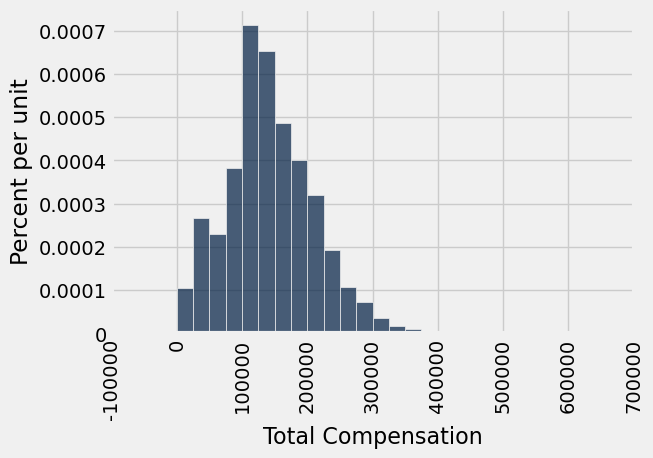

In [35]:
population.hist('Total Compensation', bins=np.arange(0, 600000, 25000))

In [37]:
pop_median = percentile(50, population.column('Total Compensation'))
pop_median

135747.0

In [38]:
# np.median works too!
np.median(population.column('Total Compensation'))

135747.0

## Let's pretend we took a sample of 400 people, and that's all we have

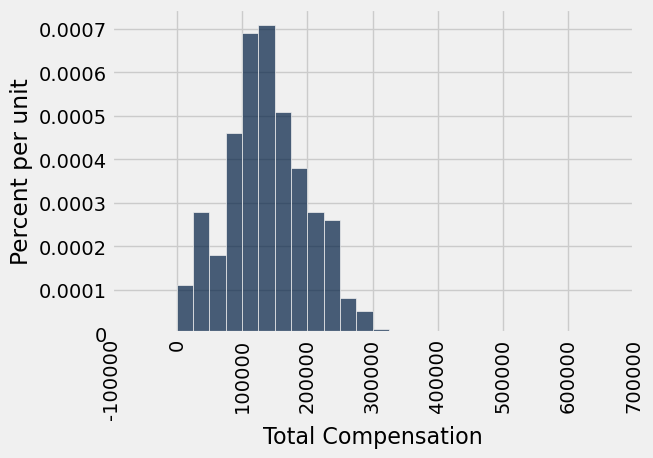

In [39]:
sample_size = 400
sample = population.sample(sample_size, with_replacement=False) # 400 separate people
sample.hist('Total Compensation', bins=np.arange(0, 600000, 25000))

In [40]:
percentile(50, sample.column('Total Compensation'))

130777.0

132854.0

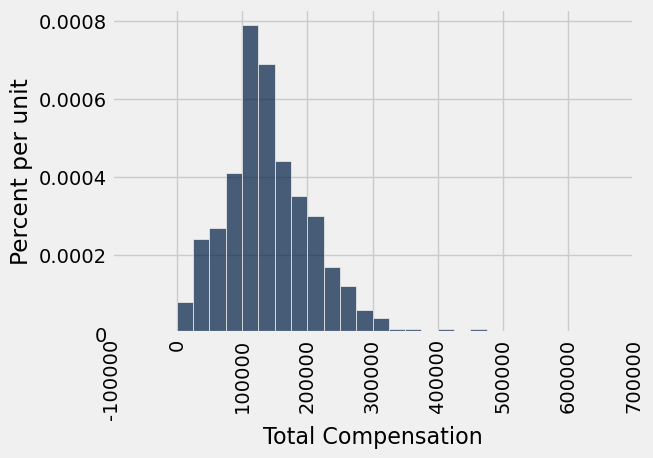

In [43]:
# usually, you can't get another sample like this!
sample_size = 400
sample2 = population.sample(sample_size, with_replacement=False) # 400 separate people
sample2.hist('Total Compensation', bins=np.arange(0, 600000, 25000))
percentile(50, sample2.column('Total Compensation'))

In [53]:
resample = sample.sample(sample.num_rows, with_replacement=True) # sample.sample() would work here
percentile(50, resample.column('Total Compensation'))

132779.0

In [54]:
def one_bootstrap_median():
    # draw the bootstrap sample
    resample = sample.sample(sample.num_rows, with_replacement=True) # sample.sample() would work here
    # return the median total comp. in the bootstrap sample
    return percentile(50, resample.column('Total Compensation'))

In [55]:
bootstrapped_sample_medians = make_array()
num_resamples = 1000

for i in np.arange(num_resamples):
    new_median = one_bootstrap_median()
    bootstrapped_sample_medians = np.append(bootstrapped_sample_medians, new_median)

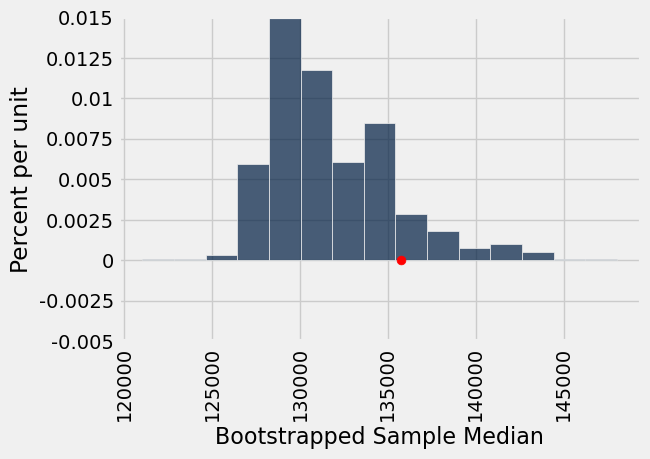

In [58]:
bootstrapped_median_table = Table().with_column('Bootstrapped Sample Median', bootstrapped_sample_medians)
bootstrapped_median_table.hist(bins=15)

plt.ylim(-0.00005, 0.00015)
plt.scatter(pop_median, 0, color='red', s=40);

In [59]:
# middle 95% of our estimates gives us an estimate that's correct 95% of the time
# 2.5% -- 97.5% is the range we want here -- that's the middle 95%
# called a *confidence interval*
percentile(2.5, bootstrapped_sample_medians), percentile(97.5, bootstrapped_sample_medians)

(126684.0, 141365.0)

In [60]:
# 90% confidence interval
percentile(5, bootstrapped_sample_medians), percentile(95, bootstrapped_sample_medians)

(127341.0, 138017.0)

In [61]:
population_mean = population.column('Total Compensation').mean()
population_mean

142675.017788319

In [ ]:
# Crushed ICE: using boostrap sampling and our size 400 sample, 
# calculate a 95% confidence interval for the average total comp.

In [62]:
sample.column('Total Compensation').mean()

137110.5025

In [63]:
def one_bootstrap_average():
    # draw the bootstrap sample
    resample = sample.sample()
    # return the average total comp. in the bootstrap sample
    return np.average(resample.column('Total Compensation'))

In [68]:
one_bootstrap_average()

144191.44

In [69]:
bootstrapped_sample_averages = make_array()
num_resamples = 1000

for i in np.arange(num_resamples):
    new_average = one_bootstrap_average()
    bootstrapped_sample_averages = np.append(bootstrapped_sample_averages, new_average)

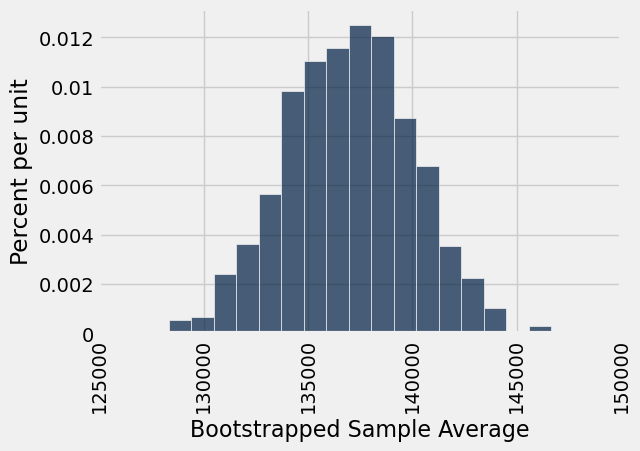

In [71]:
Table().with_column('Bootstrapped Sample Average', bootstrapped_sample_averages).hist(bins=20)

In [72]:
percentile(2.5, bootstrapped_sample_averages), percentile(97.5, bootstrapped_sample_averages)

(130914.145, 142984.535)

---

# Confidence Intervals

In [2]:
births = Table.read_table('data/baby.csv')
births

Birth Weight,Gestational Days,Maternal Age,Maternal Height,Maternal Pregnancy Weight,Maternal Smoker
120,284,27,62,100,False
113,282,33,64,135,False
128,279,28,64,115,True
108,282,23,67,125,True
136,286,25,62,93,False
138,244,33,62,178,False
132,245,23,65,140,False
120,289,25,62,125,False
143,299,30,66,136,True
140,351,27,68,120,False


In [3]:
# we have no population data this time--just a sample!

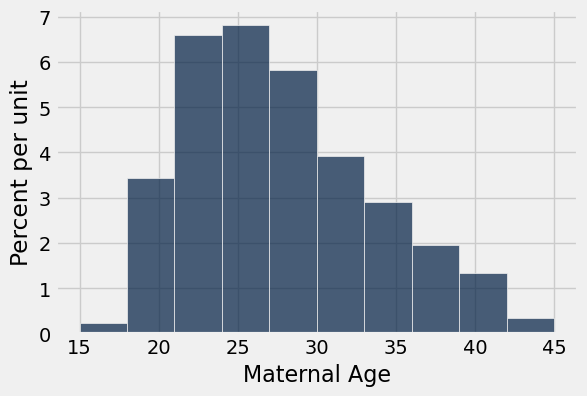

In [4]:
births.hist('Maternal Age')

In [5]:
np.average(births.column('Maternal Age'))

27.228279386712096

In [ ]:
# Crushed ICE: create a function that resamples from our original sample
# and give back the average age of the mothers in that new bootstraped sample

In [6]:
def one_bootstrap_mean():
    resample = births.sample()
    return np.average(resample.column('Maternal Age'))

In [13]:
one_bootstrap_mean()

27.324531516183985

In [14]:
# Generate means from 5000 bootstrap samples
num_repetitions = 5000
bstrap_means = make_array()
for i in np.arange(num_repetitions):
    bstrap_means = np.append(bstrap_means, one_bootstrap_mean())

In [ ]:
# Crushed ICE: calculate a 95% confidence interval using the bstrap_means array

In [15]:
left = percentile(2.5, bstrap_means)
right = percentile(97.5, bstrap_means)
make_array(left, right)

array([ 26.90289608,  27.55792164])

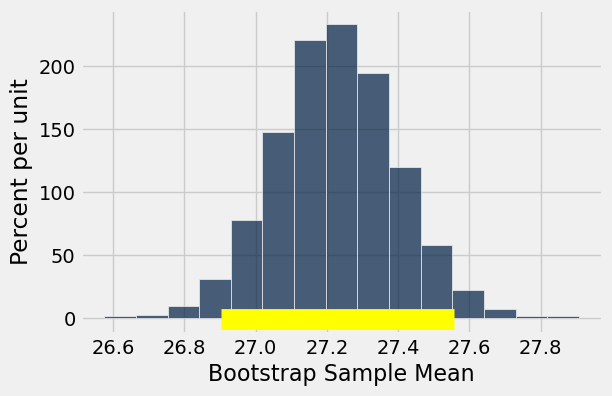

In [19]:
resampled_means = Table().with_column(
    'Bootstrap Sample Mean', bstrap_means
)
resampled_means.hist(bins=15)
plt.plot([left, right], [-.01, -.01], color='yellow', lw=15);

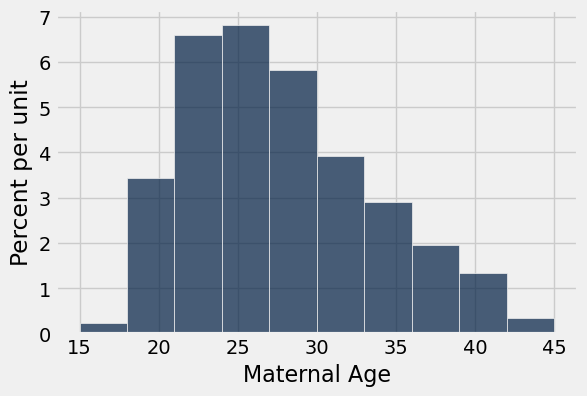

In [20]:
births.hist('Maternal Age') # ^ looks like a bell curve, even though the original distribution doesn't

In [ ]:
# confidence intervals can also be used to test hypotheses!
# Null hypothesis: The average age in the population is 30 years old.
# Alternative hypothesis: The average age in the population is not 30 years old.

In [21]:
percentile(0.5, bstrap_means), percentile(99.5, bstrap_means) # 99% confidence interval

(26.799829642248721, 27.683134582623509)

## Titanic

In [22]:
titanic = Table.read_table('data/titanic.csv')
titanic

PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.25,nan,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.925,nan,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1,C123,S
5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.05,nan,S
6,0,3,"Moran, Mr. James",male,nan,0,0,330877,8.4583,nan,Q
7,0,1,"McCarthy, Mr. Timothy J",male,54,0,0,17463,51.8625,E46,S
8,0,3,"Palsson, Master. Gosta Leonard",male,2,3,1,349909,21.075,nan,S
9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27,0,2,347742,11.1333,nan,S
10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14,1,0,237736,30.0708,nan,C


In [25]:
titanic2 = titanic.where('Age', are.above_or_equal_to(0))
titanic2

PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.25,nan,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.925,nan,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1,C123,S
5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.05,nan,S
7,0,1,"McCarthy, Mr. Timothy J",male,54,0,0,17463,51.8625,E46,S
8,0,3,"Palsson, Master. Gosta Leonard",male,2,3,1,349909,21.075,nan,S
9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27,0,2,347742,11.1333,nan,S
10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14,1,0,237736,30.0708,nan,C
11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4,1,1,PP 9549,16.7,G6,S


In [27]:
# take a size 100 sample without replacement
sample = titanic2.sample(100, with_replacement=False)
# make a function to generate a resample from your original sample and give back the avg. age
def one_bootstrap_average():
    resample = sample.sample()
    return resample.column('Age').mean()

In [35]:
# Generate averages from 5000 bootstrap samples
num_repetitions = 5000
bstrap_means = make_array()
for i in np.arange(num_repetitions):
    bstrap_means = np.append(bstrap_means, one_bootstrap_average())

In [36]:
# Get a 95% confidence interval for the average age
percentile(2.5, bstrap_means), percentile(97.5, bstrap_means)

(27.489999999999998, 32.979999999999997)

In [38]:
titanic2.column('Age').mean()

29.69911764705882

In [39]:
titanic

PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.25,nan,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.925,nan,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1,C123,S
5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.05,nan,S
6,0,3,"Moran, Mr. James",male,nan,0,0,330877,8.4583,nan,Q
7,0,1,"McCarthy, Mr. Timothy J",male,54,0,0,17463,51.8625,E46,S
8,0,3,"Palsson, Master. Gosta Leonard",male,2,3,1,349909,21.075,nan,S
9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27,0,2,347742,11.1333,nan,S
10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14,1,0,237736,30.0708,nan,C


In [40]:
# Construct a 99% confidence interval for the survival rate for a size 100 sample!

In [42]:
sample = titanic.sample(100, with_replacement=False)

def one_bootstrap_rate():
    resample = sample.sample()
    return np.average(resample.column('Survived'))

In [48]:
one_bootstrap_rate()

0.46999999999999997

In [49]:
num_repetitions = 5000
bstrap_rates = make_array()
for i in np.arange(num_repetitions):
    bstrap_rates = np.append(bstrap_rates, one_bootstrap_rate())

In [50]:
percentile(0.5, bstrap_rates), percentile(99.5, bstrap_rates)

(0.31, 0.56999999999999995)

In [51]:
titanic.column('Survived').mean()

0.38383838383838381

In [52]:
# Try to change the sample size and see how the width of the interval changes!

## Fish Diet

In [56]:
diet = Table.read_table('data/fish-diet.csv')
diet.sample()

Diet,Cancer
Small,No
Moderate,Yes
Moderate,No
Large,No
Moderate,Yes
Moderate,No
Moderate,No
Never,No
Small,No
Moderate,No


In [57]:
# Take a size 100 sample
# Construct a 90% confidence interval for the total cancer rate 
# (among all the kinds of fish diets taken together)

In [59]:
np.average(diet.column('Cancer') == 'Yes')

0.074298469387755098

In [63]:
S = diet.sample(100, with_replacement=False)

def one_bootstrap_rate():
    resample = S.sample()
    return np.average(resample.column('Cancer') == 'Yes')

num_repetitions = 5000
bstrap_rates = make_array()
for i in np.arange(num_repetitions):
    bstrap_rates = np.append(bstrap_rates, one_bootstrap_rate())

percentile(5, bstrap_rates), percentile(95, bstrap_rates)

(0.040000000000000001, 0.13)

In [64]:
# The dataset itself was a sample! Let's use the whole thing to predict the average cancer
# rate for Swedish men!

In [65]:
def one_bootstrap_rate():
    resample = diet.sample() # use the whole dataset
    return np.average(resample.column('Cancer') == 'Yes')

num_repetitions = 1000
bstrap_rates = make_array()
for i in np.arange(num_repetitions):
    bstrap_rates = np.append(bstrap_rates, one_bootstrap_rate())

percentile(5, bstrap_rates), percentile(95, bstrap_rates)

(0.068877551020408156, 0.079878826530612249)

In [66]:
percentile(2.5, bstrap_rates), percentile(97.5, bstrap_rates)

(0.067442602040816327, 0.080676020408163268)

## Pokemon

In [67]:
pokemon = Table.read_table('data/pokemon.csv')
pokemon

abilities,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,against_grass,against_ground,against_ice,against_normal,against_poison,against_psychic,against_rock,against_steel,against_water,attack,base_egg_steps,base_happiness,base_total,capture_rate,classfication,defense,experience_growth,height_m,hp,japanese_name,name,percentage_male,pokedex_number,sp_attack,sp_defense,speed,type1,type2,weight_kg,generation,is_legendary
"['Overgrow', 'Chlorophyll']",1,1,1,0.5,0.5,0.5,2,2,1,0.25,1,2,1,1,2,1,1,0.5,49,5120,70,318,45,Seed Pokémon,49,1059860,0.7,45,Fushigidaneフシギダネ,Bulbasaur,88.1,1,65,65,45,grass,poison,6.9,1,0
"['Overgrow', 'Chlorophyll']",1,1,1,0.5,0.5,0.5,2,2,1,0.25,1,2,1,1,2,1,1,0.5,62,5120,70,405,45,Seed Pokémon,63,1059860,1,60,Fushigisouフシギソウ,Ivysaur,88.1,2,80,80,60,grass,poison,13,1,0
"['Overgrow', 'Chlorophyll']",1,1,1,0.5,0.5,0.5,2,2,1,0.25,1,2,1,1,2,1,1,0.5,100,5120,70,625,45,Seed Pokémon,123,1059860,2,80,Fushigibanaフシギバナ,Venusaur,88.1,3,122,120,80,grass,poison,100,1,0
"['Blaze', 'Solar Power']",0.5,1,1,1,0.5,1,0.5,1,1,0.5,2,0.5,1,1,1,2,0.5,2,52,5120,70,309,45,Lizard Pokémon,43,1059860,0.6,39,Hitokageヒトカゲ,Charmander,88.1,4,60,50,65,fire,nan,8.5,1,0
"['Blaze', 'Solar Power']",0.5,1,1,1,0.5,1,0.5,1,1,0.5,2,0.5,1,1,1,2,0.5,2,64,5120,70,405,45,Flame Pokémon,58,1059860,1.1,58,Lizardoリザード,Charmeleon,88.1,5,80,65,80,fire,nan,19,1,0
"['Blaze', 'Solar Power']",0.25,1,1,2,0.5,0.5,0.5,1,1,0.25,0,1,1,1,1,4,0.5,2,104,5120,70,634,45,Flame Pokémon,78,1059860,1.7,78,Lizardonリザードン,Charizard,88.1,6,159,115,100,fire,flying,90.5,1,0
"['Torrent', 'Rain Dish']",1,1,1,2,1,1,0.5,1,1,2,1,0.5,1,1,1,1,0.5,0.5,48,5120,70,314,45,Tiny Turtle Pokémon,65,1059860,0.5,44,Zenigameゼニガメ,Squirtle,88.1,7,50,64,43,water,nan,9,1,0
"['Torrent', 'Rain Dish']",1,1,1,2,1,1,0.5,1,1,2,1,0.5,1,1,1,1,0.5,0.5,63,5120,70,405,45,Turtle Pokémon,80,1059860,1,59,Kameilカメール,Wartortle,88.1,8,65,80,58,water,nan,22.5,1,0
"['Torrent', 'Rain Dish']",1,1,1,2,1,1,0.5,1,1,2,1,0.5,1,1,1,1,0.5,0.5,103,5120,70,630,45,Shellfish Pokémon,120,1059860,1.6,79,Kamexカメックス,Blastoise,88.1,9,135,115,78,water,nan,85.5,1,0
"['Shield Dust', 'Run Away']",1,1,1,1,1,0.5,2,2,1,0.5,0.5,1,1,1,1,2,1,1,30,3840,70,195,255,Worm Pokémon,35,1000000,0.3,45,Caterpieキャタピー,Caterpie,50,10,20,20,45,bug,nan,2.9,1,0


In [69]:
sample = pokemon.sample(150, with_replacement=False)

def one_bootstrap_median():
    resample = sample.sample()
    return np.median(resample.column('hp'))

num_repetitions = 5000
bstrap_medians = make_array()
for i in np.arange(num_repetitions):
    bstrap_medians = np.append(bstrap_medians, one_bootstrap_median())

percentile(2.5, bstrap_medians), percentile(97.5, bstrap_medians)

(64.0, 70.0)

In [70]:
np.median(pokemon.column('hp'))

65.0